In [2]:
!pip install datasets --quiet

from datasets import load_dataset

# Load IMDB from HuggingFace
dataset = load_dataset("imdb")

train_data = dataset['train']
test_data  = dataset['test']

print(f"Train size: {len(train_data)}")   # 25000
print(f"Test size:  {len(test_data)}")    # 25000

# Check structure
print(f"\nSample label: {train_data[0]['label']}")
print(f"Sample text (first 200 chars): {train_data[0]['text'][:200]}")
print(f"\nUnique labels: {set(train_data['label'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 25000
Test size:  25000

Sample label: 0
Sample text (first 200 chars): I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

Unique labels: {0, 1}


In [6]:
import re
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader

# ── Text Cleaning ─────────────────────────────────────────────────────────────
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)    # remove HTML line breaks
    text = re.sub(r'[^a-z0-9\s]', '', text)  # keep only letters and numbers
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── Build Vocabulary ──────────────────────────────────────────────────────────
MAX_VOCAB = 10000   # keep top 10k most frequent words
MAX_LEN   = 200     # truncate/pad all reviews to 200 tokens

# Tokenize and count all words in training set
counter = Counter()
for item in train_data:
    tokens = clean_text(item['text']).split()
    counter.update(tokens)

# Build vocab: 0=PAD, 1=UNK, then top words
vocab = {'<PAD>': 0, '<UNK>': 1}
for word, _ in counter.most_common(MAX_VOCAB - 2):
    vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")   # 10000

# ── Encode Text to Integer Sequence ──────────────────────────────────────────
def encode(text, vocab, max_len):
    tokens = clean_text(text).split()[:max_len]
    ids    = [vocab.get(token, 1) for token in tokens]  # 1 = UNK
    # Pad to max_len
    ids    = ids + [0] * (max_len - len(ids))
    return ids

# ── Build Dataset ─────────────────────────────────────────────────────────────
class IMDBDataset(Dataset):
    def __init__(self, data, vocab, max_len):
        self.X = [encode(item['text'], vocab, max_len) for item in data]
        self.y = [item['label'] for item in data]

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        return (torch.tensor(self.X[idx], dtype=torch.long),
                torch.tensor(self.y[idx], dtype=torch.float))

train_dataset = IMDBDataset(train_data, vocab, MAX_LEN)
test_dataset  = IMDBDataset(test_data,  vocab, MAX_LEN)

train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=64, shuffle=False)

# ── Verify ────────────────────────────────────────────────────────────────────
X_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape: {X_batch.shape}")   # [64, 200]
print(f"Batch y shape: {y_batch.shape}")   # [64]
print(f"Sample encoded: {X_batch[0][:20]}")  # first 20 token ids
print(f"Sample label: {y_batch[0]}")

Vocabulary size: 10000
Batch X shape: torch.Size([64, 200])
Batch y shape: torch.Size([64])
Sample encoded: tensor([  10,  102,   12,   11,   17,   13,    1,   49,   29, 1859,  896,   12,
         148,    2, 7646, 4928,   23, 2544,    3,   25])
Sample label: 1.0


In [8]:
import torch.nn as nn

# ── GRU Model ─────────────────────────────────────────────────────────────────
class SentimentGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout):
        super(SentimentGRU, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings = vocab_size,
            embedding_dim  = embed_dim,
            padding_idx     = 0          # PAD token won't update during training
        )

        self.gru = nn.GRU(
            input_size  = embed_dim,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
            bidirectional = True        # read sequence forward AND backward
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),  # *2 because bidirectional
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
            # No Sigmoid — using BCEWithLogitsLoss
        )

    def forward(self, x):
        embedded = self.embedding(x)          # [batch, seq, embed_dim]
        out, _   = self.gru(embedded)         # [batch, seq, hidden*2]
        last_step = out[:, -1, :]             # take last timestep
        return self.classifier(last_step).squeeze(1)


# ── Initialize ────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SentimentGRU(
    vocab_size   = 10000,
    embed_dim    = 128,
    hidden_size  = 128,
    num_layers   = 2,
    dropout      = 0.3
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

total_params = sum(p.numel() for p in model.parameters())
print(f"Device: {device}")
print(f"Total parameters: {total_params:,}")

# Test forward pass
sample = torch.randint(0, 10000, (64, 200)).to(device)
output = model(sample)
print(f"Output shape: {output.shape}")   # torch.Size([64])


# ── Training Loop ─────────────────────────────────────────────────────────────
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=10):
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0.0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss    += loss.item() * X_batch.size(0)
            preds          = (torch.sigmoid(logits) >= 0.5).float()
            train_correct += (preds == y_batch).sum().item()

        model.eval()
        val_loss, val_correct = 0.0, 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)

                val_loss    += loss.item() * X_batch.size(0)
                preds        = (torch.sigmoid(logits) >= 0.5).float()
                val_correct += (preds == y_batch).sum().item()

        train_loss = train_loss / len(train_loader.dataset)
        train_acc  = train_correct / len(train_loader.dataset)
        val_loss   = val_loss / len(test_loader.dataset)
        val_acc    = val_correct / len(test_loader.dataset)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_sentiment_gru.pth')
            print(f"  → Best model saved (val_acc: {val_acc:.4f})")

    print(f"\nTraining complete. Best Val Acc: {best_val_acc:.4f}")
    return history

# ── Run ───────────────────────────────────────────────────────────────────────
history = train_model(model, train_loader, test_loader, criterion, optimizer, epochs=10)

Device: cuda
Total parameters: 1,791,105
Output shape: torch.Size([64])
Epoch [01/10] Train Loss: 0.6923 Acc: 0.5123 | Val Loss: 0.6822 Acc: 0.5451
  → Best model saved (val_acc: 0.5451)
Epoch [02/10] Train Loss: 0.6002 Acc: 0.6560 | Val Loss: 0.4471 Acc: 0.7934
  → Best model saved (val_acc: 0.7934)
Epoch [03/10] Train Loss: 0.3497 Acc: 0.8533 | Val Loss: 0.3496 Acc: 0.8510
  → Best model saved (val_acc: 0.8510)
Epoch [04/10] Train Loss: 0.2445 Acc: 0.9031 | Val Loss: 0.3171 Acc: 0.8633
  → Best model saved (val_acc: 0.8633)
Epoch [05/10] Train Loss: 0.1662 Acc: 0.9397 | Val Loss: 0.3961 Acc: 0.8501
Epoch [06/10] Train Loss: 0.1043 Acc: 0.9658 | Val Loss: 0.4392 Acc: 0.8561
Epoch [07/10] Train Loss: 0.0597 Acc: 0.9818 | Val Loss: 0.5668 Acc: 0.8569
Epoch [08/10] Train Loss: 0.0386 Acc: 0.9884 | Val Loss: 0.6069 Acc: 0.8545
Epoch [09/10] Train Loss: 0.0261 Acc: 0.9926 | Val Loss: 0.7350 Acc: 0.8531
Epoch [10/10] Train Loss: 0.0235 Acc: 0.9928 | Val Loss: 0.6826 Acc: 0.8503

Training co

In [10]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model = SentimentGRU(
    vocab_size   = 10000,
    embed_dim    = 128,
    hidden_size  = 128,
    num_layers   = 2,
    dropout      = 0.5       # increased from 0.3
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # L2 regularization

# Reduce LR when val loss stops improving
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

def train_model_v2(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs=15):
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0.0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss    += loss.item() * X_batch.size(0)
            preds          = (torch.sigmoid(logits) >= 0.5).float()
            train_correct += (preds == y_batch).sum().item()

        model.eval()
        val_loss, val_correct = 0.0, 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)

                val_loss    += loss.item() * X_batch.size(0)
                preds        = (torch.sigmoid(logits) >= 0.5).float()
                val_correct += (preds == y_batch).sum().item()

        train_loss = train_loss / len(train_loader.dataset)
        train_acc  = train_correct / len(train_loader.dataset)
        val_loss   = val_loss / len(test_loader.dataset)
        val_acc    = val_correct / len(test_loader.dataset)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_sentiment_gru.pth')
            print(f"  → Best model saved (val_acc: {val_acc:.4f})")

    print(f"\nTraining complete. Best Val Acc: {best_val_acc:.4f}")
    return history

history = train_model_v2(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs=15)

Epoch [01/15] Train Loss: 0.6933 Acc: 0.5033 | Val Loss: 0.6926 Acc: 0.5084
  → Best model saved (val_acc: 0.5084)
Epoch [02/15] Train Loss: 0.6930 Acc: 0.5074 | Val Loss: 0.6911 Acc: 0.5175
  → Best model saved (val_acc: 0.5175)
Epoch [03/15] Train Loss: 0.6903 Acc: 0.5152 | Val Loss: 0.6923 Acc: 0.5316
  → Best model saved (val_acc: 0.5316)
Epoch [04/15] Train Loss: 0.6910 Acc: 0.5243 | Val Loss: 0.6920 Acc: 0.5251
Epoch [05/15] Train Loss: 0.6896 Acc: 0.5454 | Val Loss: 0.6849 Acc: 0.5671
  → Best model saved (val_acc: 0.5671)
Epoch [06/15] Train Loss: 0.6905 Acc: 0.5167 | Val Loss: 0.6932 Acc: 0.5000
Epoch [07/15] Train Loss: 0.6932 Acc: 0.5003 | Val Loss: 0.6932 Acc: 0.5000
Epoch [08/15] Train Loss: 0.6932 Acc: 0.5000 | Val Loss: 0.6931 Acc: 0.5000
Epoch [09/15] Train Loss: 0.6932 Acc: 0.4980 | Val Loss: 0.6931 Acc: 0.5000
Epoch [10/15] Train Loss: 0.6932 Acc: 0.4976 | Val Loss: 0.6931 Acc: 0.5000
Epoch [11/15] Train Loss: 0.6931 Acc: 0.4952 | Val Loss: 0.6929 Acc: 0.5000
Epoch [1

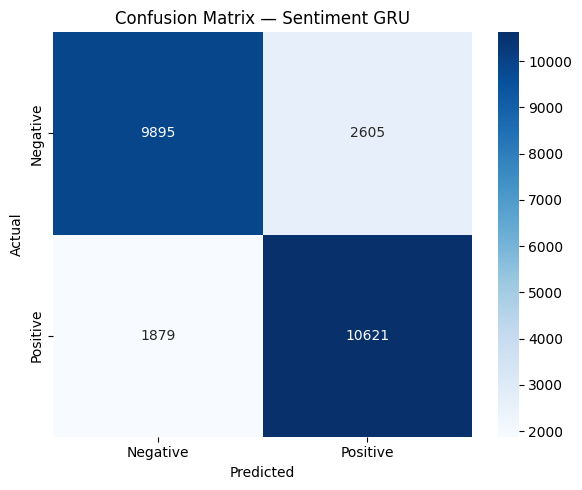

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.79      0.82     12500
    Positive       0.80      0.85      0.83     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000



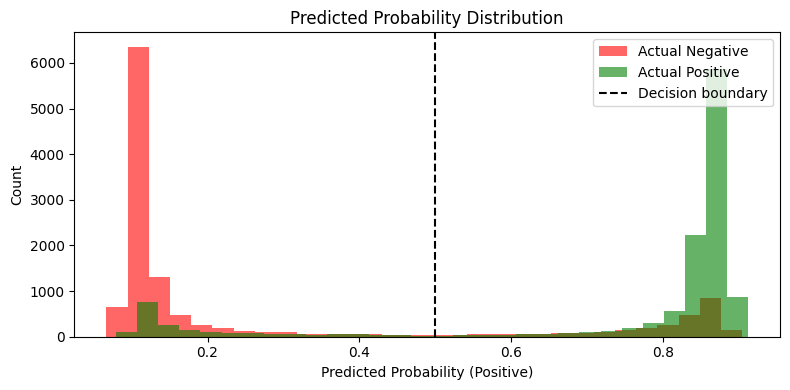

Review: This movie was absolutely fantastic! Best film I have seen in years....
Prediction: Positive (confidence: 0.857)

Review: Terrible movie. Complete waste of time. Worst acting I have ever seen....
Prediction: Negative (confidence: 0.115)

Review: It was okay. Nothing special but not bad either....
Prediction: Negative (confidence: 0.115)

Review: Started slow but the ending was brilliant and very emotional....
Prediction: Positive (confidence: 0.857)



In [11]:
# ── Reload best model from first training run ─────────────────────────────────
model = SentimentGRU(
    vocab_size   = 10000,
    embed_dim    = 128,
    hidden_size  = 128,
    num_layers   = 2,
    dropout      = 0.3
).to(device)

model.load_state_dict(torch.load('best_sentiment_gru.pth'))
model.eval()

# ── Evaluation ────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        probs   = torch.sigmoid(logits).cpu().numpy()
        preds   = (probs >= 0.5).astype(float)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Sentiment GRU')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('sentiment_confusion_matrix.png', dpi=150)
plt.show()

# ── Classification Report ─────────────────────────────────────────────────────
print("Classification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=['Negative', 'Positive']))

# ── Probability Distribution ──────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(all_probs[all_labels==0], bins=30, alpha=0.6, label='Actual Negative', color='red')
plt.hist(all_probs[all_labels==1], bins=30, alpha=0.6, label='Actual Positive', color='green')
plt.axvline(x=0.5, color='black', linestyle='--', label='Decision boundary')
plt.title('Predicted Probability Distribution')
plt.xlabel('Predicted Probability (Positive)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('sentiment_prob_distribution.png', dpi=150)
plt.show()

# ── Test on Custom Reviews ────────────────────────────────────────────────────
def predict_sentiment(text, model, vocab, max_len=200):
    model.eval()
    encoded = encode(text, vocab, max_len)
    tensor  = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        logit = model(tensor)
        prob  = torch.sigmoid(logit).item()
    label = "Positive" if prob >= 0.5 else "Negative"
    print(f"Review: {text[:80]}...")
    print(f"Prediction: {label} (confidence: {prob:.3f})\n")

# Test with real examples
predict_sentiment("This movie was absolutely fantastic! Best film I have seen in years.", model, vocab)
predict_sentiment("Terrible movie. Complete waste of time. Worst acting I have ever seen.", model, vocab)
predict_sentiment("It was okay. Nothing special but not bad either.", model, vocab)
predict_sentiment("Started slow but the ending was brilliant and very emotional.", model, vocab)